### АНАЛИЗ ЭФФЕКТИВНОСТИ ДВУХ ВАРИАНТОВ ПОСАДОЧНОЙ СТРАНИЦЫ

**Сценарий:**

Data Scientist в туристической фирме. Компания планирует запустить новую акцию, чтобы продать как можно больше туров. Команда разработала два варианта посадочной страницы официального сайта и провела A/B-тестирование. В результате эксперимента были собраны данные "ab_data_tourist.csv".

**Бизнес Задача:**

Решить настоящую бизнес-задачу: проанализировать эффективность обоих вариантов посадочной страницы сразу по двум критериям — **конверсии покупки** и **ежедневному среднему чеку**.

**Технические требования:**

Необходимо убедиться, что A/B-тестирование было проведено корректно, проверить факт стабилизации метрик и обоснованно ответить на ключевой вопрос турагентства: какой вариант посадочной страницы более предпочтителен по метрикам конверсии и ежедневного среднего чека?

Компания предлагает следующие варианты туров:

- Таиланд — 100 000 рублей;
- Турция — 60 000 рублей;
- Мальдивы — 200 000 рублей;
- Санкт-Петербург — 10 000 рублей;
- Камчатка — 150 000 рублей.



Импорт библиотек:

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from math import sqrt
from scipy import stats
from scipy.stats import norm

Прочитаем наши данные и посмотрим на столбцы таблицы:

In [68]:
data = pd.read_csv('data/ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


Наша таблица представлена следующими полями:

- user_id — идентификатор пользователя, зашедшего на сайт;
- date — дата посещения сайта;
- group — группа теста (контрольная — А или тестовая — B);
- purchase — признак покупки: совершил ли пользователь покупку тура (1 — да, 0 — нет);
- price — цена купленного тура (если покупка не состоялась, цена равна 0).

### Задание разделено на 5 пунктов, предварительные выводу будут приведены к каждой части

### Задание #1

Проанализируйте структуру данных и проведите их предобработку:

- исследуйте структуру данных;
- преобразуйте столбцы к необходимым типам данных.
- Убедитесь в одинаковой длительности проведения A/B-тестирования в каждой из групп. Если длительность разная, унифицируйте данные, удалив лишние данные для соответствующей группы.
- Проверьте данные на наличие пропусков и избавьтесь от них, если нужно.
- Проверьте, есть ли пользователи, которые в процессе A/B-теста попали в обе группы. Если да, исключите пользователей, оказавшихся в обеих группах.

In [69]:
# исследовать структуру данных

# Работаем с копией, чтобы сохранить исходный датафрейм data
ab_data = data.copy()

print('Исходная структура данных:')
print(f'Shape: {ab_data.shape}')
display(ab_data.head())
display(ab_data.dtypes)

Исходная структура данных:
Shape: (294478, 5)


,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


user_id      int64
date        object
group       object
purchase     int64
price        int64
dtype: object

In [70]:
# преобразуем столбцы к необходимым типам данных.

ab_data['date'] = pd.to_datetime(ab_data['date'], errors='coerce')
ab_data['user_id'] = pd.to_numeric(ab_data['user_id'], errors='coerce')
ab_data['purchase'] = pd.to_numeric(ab_data['purchase'], errors='coerce')
ab_data['price'] = pd.to_numeric(ab_data['price'], errors='coerce')
ab_data['group'] = ab_data['group'].astype('string').str.upper().astype('category')

print('\nТипы данных после преобразования')
display(ab_data.dtypes)


Типы данных после преобразования


user_id              int64
date        datetime64[ns]
group             category
purchase             int64
price                int64
dtype: object

In [71]:
# Проверка одинаковой длительности теста для группы А и группы B. Для этого сгруппируем данные по признаку group и для каждой группы посчитаем минимальную и максимальную дату.
# Если даты совпадают, то тест проводился одинаковое количество дней для обеих групп.
periods = (
    ab_data.groupby('group', observed=True)['date']
    .agg(['min', 'max'])
    .rename(columns={'min': 'start_date', 'max': 'end_date'})
)

print('\nПериоды A/B-теста по группам')
display(periods)


Периоды A/B-теста по группам


,start_date,end_date
group,,
A,2021-01-02,2021-01-24
B,2021-01-02,2021-01-24


In [72]:
# Проверка на пропуски и удаление
print('\nКоличество пропусков')
display(ab_data.isna().sum())

rows_before_na = len(ab_data)
ab_data = ab_data.dropna(subset=['user_id', 'date', 'group', 'purchase', 'price']).copy()
rows_after_na = len(ab_data)

# Финальное приведение числовых столбцов к целым, если это возможно после удаления NaN
ab_data['user_id'] = ab_data['user_id'].astype('int64')
ab_data['purchase'] = ab_data['purchase'].astype('int8')

print(f'Удалено строк с пропусками: {rows_before_na - rows_after_na}')



Количество пропусков


user_id     0
date        0
group       0
purchase    0
price       0
dtype: int64

Удалено строк с пропусками: 0


In [73]:
# Поиск пользователей, попавших в обе группы, и их исключение
cross_users = (
    ab_data.groupby('user_id', observed=True)['group']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

print(f'\n Пользователей в обеих группах: {len(cross_users)}')

rows_before_cross = len(ab_data)
if len(cross_users) > 0:
    ab_data = ab_data[~ab_data['user_id'].isin(cross_users)].copy()
rows_after_cross = len(ab_data)

print(f'Удалено строк из-за пересечения пользователей: {rows_before_cross - rows_after_cross}')
print(f'Итоговый размер очищенного датасета: {ab_data.shape}')


 Пользователей в обеих группах: 1895
Удалено строк из-за пересечения пользователей: 3790
Итоговый размер очищенного датасета: (290688, 5)


> Вывод:
> - даты совпадают, тест проводился одинаковое количество дней для обеих групп.
> - пропуски отсутствуют 
> - 1895 пользователя попали в обе группы, они были исключены из обоих групп

### Задание #2

Сделайте первичный анализ результатов A/B-тестирования:

1. Рассчитайте вспомогательные показатели для контрольной и тестовой групп:
    - количество посещений сайта;
    - суммарное количество совершённых покупок;
    - сумма всех покупок.
    
    Сделайте промежуточные выводы по построенной таблице. Сопоставимо ли количество посещений обоих вариантов посадочной страницы? Можно ли говорить о сбалансированности выборок?

2. В каждой из групп рассчитайте ключевые показатели:

    - конверсия;
    - средний чек.
    
    Сделайте первичные выводы о результатах A/B-тестирования на основе показателей конверсии и среднего чека в каждой из групп. По какому(-им) показателю(-ям), на первый взгляд, вариант А эффективнее варианта B и наоборот?

3. Сравните варианты A/B по покупательской способности каждого из туров. Для этого постройте сводную таблицу, которая покажет зависимость количества продаж от группы и цены тура. Визуализируйте полученную сводную таблицу.

    Сделайте выводы по построенной таблице. По каким турам покупательская способность участников группы А выше, чем покупательская способность участников группы B, и наоборот?

In [74]:
# Используем очищенный на предыдущем шаге датасет
analysis_data = ab_data.copy()

# Вспомогательные показатели
aux_metrics = (
    analysis_data.groupby('group', observed=True)
    .agg(
        visits=('user_id', 'count'),
        purchases=('purchase', 'sum'),
        revenue=('price', 'sum')
    )
    .sort_index()
)

display(aux_metrics)

visits_ratio = aux_metrics['visits'].max() / aux_metrics['visits'].min()
print(f"Отношение max/min по посещениям: {visits_ratio:.4f}")



,visits,purchases,revenue
group,,,
A,145307,17487,1417780000
B,145381,17290,1533010000


Отношение max/min по посещениям: 1.0005


In [75]:
# Ключевые показатели
key_metrics = aux_metrics.copy()
key_metrics['conversion'] = key_metrics['purchases'] / key_metrics['visits']
key_metrics['avg_check'] = key_metrics['revenue'] / key_metrics['purchases']

display(key_metrics)

conv_diff_pp = (key_metrics.loc['B', 'conversion'] - key_metrics.loc['A', 'conversion']) * 100
avg_check_diff = key_metrics.loc['B', 'avg_check'] - key_metrics.loc['A', 'avg_check']

print(f"Разница в конверсии (B - A): {conv_diff_pp:.2f} п.п.")
print(f"Разница в среднем чеке (B - A): {avg_check_diff:,.2f}")


,visits,purchases,revenue,conversion,avg_check
group,,,,,
A,145307,17487,1417780000,0.120345,81076.228055
B,145381,17290,1533010000,0.118929,88664.545980


Разница в конверсии (B - A): -0.14 п.п.
Разница в среднем чеке (B - A): 7,588.32


C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_22812\2806287311.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tour_sales = pd.pivot_table(


group,A,B
price,,
10000,5182,5201
60000,5271,1730
100000,1832,5227
150000,3478,3438
200000,1724,1694


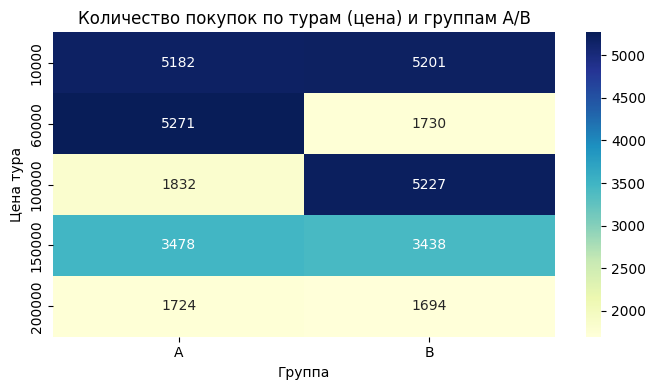

Туры, где покупок больше в группе A: [60000, 150000, 200000]
Туры, где покупок больше в группе B: [10000, 100000]
Туры с одинаковым числом покупок: []


In [76]:
# Покупательская способность по турам (ценам)
tour_sales = pd.pivot_table(
    analysis_data[analysis_data['purchase'] == 1],
    values='user_id',
    index='price',
    columns='group',
    aggfunc='count',
    fill_value=0
).astype(int).sort_index()

display(tour_sales)

plt.figure(figsize=(7, 4))
sns.heatmap(tour_sales, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Количество покупок по турам (цена) и группам A/B')
plt.xlabel('Группа')
plt.ylabel('Цена тура')
plt.tight_layout()
plt.show()

tour_compare = tour_sales.copy()
tour_compare['leader'] = tour_compare.apply(
    lambda row: 'A' if row.get('A', 0) > row.get('B', 0)
    else ('B' if row.get('B', 0) > row.get('A', 0) else 'equal'),
    axis=1
)

a_better = tour_compare.index[tour_compare['leader'] == 'A'].tolist()
b_better = tour_compare.index[tour_compare['leader'] == 'B'].tolist()
equal_tours = tour_compare.index[tour_compare['leader'] == 'equal'].tolist()

print('Туры, где покупок больше в группе A:', a_better)
print('Туры, где покупок больше в группе B:', b_better)
print('Туры с одинаковым числом покупок:', equal_tours)

>Вывод:
>
> 1. Объемы трафика сопоставимы, выборки можно считать сбалансированными по посещениям.
> 2. По конверсии вариант A выглядит лучше.
> 3. По среднему чеку вариант B выглядит лучше.


### Задание #3

Проанализируйте данные на предмет стабилизации метрик:

1. Сгруппируйте данные по дате и группе тестирования и постройте таблицу с ежедневными данными результатов проведения A/B-тестирования. В каждой группе вычислите ежедневные показатели:

    - количество посещений страницы;
    - количество покупок;
    - сумму покупок.

2. Добавьте в таблицу информацию о ежедневной конверсии (ежедневное количество покупок / ежедневное количество посещений) в группе и о ежедневном среднем чеке (ежедневная сумма покупок / ежедневное количество покупок).

3. Рассчитайте кумулятивные показатели:

    - кумулятивное количество посещений страницы;
    - кумулятивное количество покупок;
    - кумулятивную сумму покупок.

4. На основе полученных кумулятивных показателей вычислите кумулятивную конверсию и кумулятивный средний чек.

5. Постройте кумулятивные графики конверсии и среднего чека в каждой группе по дням.

6. Сделайте выводы. Можно ли назвать A/B-тест завершённым? Стабилизировались ли значения метрик во времени? Как соотносятся кумулятивные показатели в каждой группе?

In [77]:
# 1-2 Ежедневные метрики + ежедневная конверсия и средний чек
daily_data = (
    analysis_data
    .groupby(['date', 'group'], observed=True)
    .agg(
        visits=('user_id', 'count'),
        purchases=('purchase', 'sum'),
        revenue=('price', 'sum')
    )
    .reset_index()
    .sort_values(['group', 'date'])
)

daily_data['conversion'] = daily_data['purchases'] / daily_data['visits']
daily_data['avg_check'] = np.where(
    daily_data['purchases'] > 0,
    daily_data['revenue'] / daily_data['purchases'],
    0
)

print('Ежедневная таблица (первые строки):')
display(daily_data.head(10))


Ежедневная таблица (первые строки):


,date,group,visits,purchases,revenue,conversion,avg_check
0,2021-01-02,A,2854,359,29410000,0.125788,81922.005571
2,2021-01-03,A,6596,748,62000000,0.113402,82887.700535
4,2021-01-04,A,6566,799,64250000,0.121687,80413.016270
6,2021-01-05,A,6433,790,64550000,0.122804,81708.860759
8,2021-01-06,A,6606,764,63410000,0.115652,82997.382199
10,2021-01-07,A,6579,795,67290000,0.120839,84641.509434
12,2021-01-08,A,6687,798,65380000,0.119336,81929.824561
14,2021-01-09,A,6633,794,65610000,0.119705,82632.241814
16,2021-01-10,A,6659,759,58950000,0.113981,77667.984190
18,2021-01-11,A,6699,797,58760000,0.118973,73726.474279


In [78]:
# 3-4 Кумулятивные показатели + кумулятивная конверсия и кумулятивный средний чек
daily_data['cum_visits'] = daily_data.groupby('group', observed=True)['visits'].cumsum()
daily_data['cum_purchases'] = daily_data.groupby('group', observed=True)['purchases'].cumsum()
daily_data['cum_revenue'] = daily_data.groupby('group', observed=True)['revenue'].cumsum()

daily_data['cum_conversion'] = daily_data['cum_purchases'] / daily_data['cum_visits']
daily_data['cum_avg_check'] = np.where(
    daily_data['cum_purchases'] > 0,
    daily_data['cum_revenue'] / daily_data['cum_purchases'],
    0
)

print('Ежедневная таблица с кумулятивными метриками:')
display(daily_data.head(10))


Ежедневная таблица с кумулятивными метриками:


,date,group,visits,purchases,revenue,conversion,avg_check,cum_visits,cum_purchases,cum_revenue,cum_conversion,cum_avg_check
0,2021-01-02,A,2854,359,29410000,0.125788,81922.005571,2854,359,29410000,0.125788,81922.005571
2,2021-01-03,A,6596,748,62000000,0.113402,82887.700535,9450,1107,91410000,0.117143,82574.525745
4,2021-01-04,A,6566,799,64250000,0.121687,80413.016270,16016,1906,155660000,0.119006,81668.415530
6,2021-01-05,A,6433,790,64550000,0.122804,81708.860759,22449,2696,220210000,0.120094,81680.267062
8,2021-01-06,A,6606,764,63410000,0.115652,82997.382199,29055,3460,283620000,0.119084,81971.098266
10,2021-01-07,A,6579,795,67290000,0.120839,84641.509434,35634,4255,350910000,0.119408,82470.035253
12,2021-01-08,A,6687,798,65380000,0.119336,81929.824561,42321,5053,416290000,0.119397,82384.721947
14,2021-01-09,A,6633,794,65610000,0.119705,82632.241814,48954,5847,481900000,0.119439,82418.334188
16,2021-01-10,A,6659,759,58950000,0.113981,77667.984190,55613,6606,540850000,0.118785,81872.540115
18,2021-01-11,A,6699,797,58760000,0.118973,73726.474279,62312,7403,599610000,0.118805,80995.542348


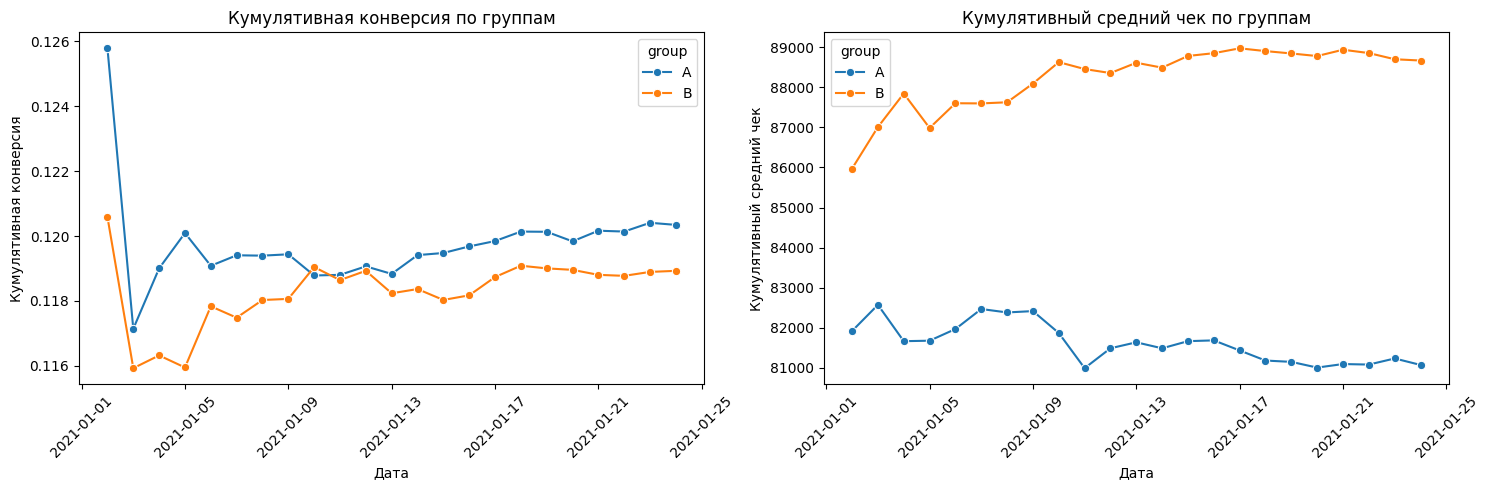

In [79]:
# 5 Кумулятивные графики по дням
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=daily_data,
    x='date',
    y='cum_conversion',
    hue='group',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Кумулятивная конверсия по группам')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Кумулятивная конверсия')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(
    data=daily_data,
    x='date',
    y='cum_avg_check',
    hue='group',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Кумулятивный средний чек по группам')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Кумулятивный средний чек')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


> Вывод: линии кумулятивных метрик на графиках выходят на плато, тест близок к стабилизации

In [80]:
# 6 Краткая диагностика стабилизации (по последним 5 дням)
window = 5
stability_tail = (
    daily_data.sort_values(['group', 'date'])
    .groupby('group', observed=True)
    .tail(window)
)

stability_summary = (
    stability_tail.groupby('group', observed=True)
    .agg(
        conv_min=('cum_conversion', 'min'),
        conv_max=('cum_conversion', 'max'),
        check_min=('cum_avg_check', 'min'),
        check_max=('cum_avg_check', 'max')
    )
)
stability_summary['conv_spread_pp'] = (stability_summary['conv_max'] - stability_summary['conv_min']) * 100
stability_summary['check_spread'] = stability_summary['check_max'] - stability_summary['check_min']

print('Сводка колебаний кумулятивных метрик за последние 5 дней:')
display(stability_summary)

final_metrics = (
    daily_data.sort_values('date')
    .groupby('group', observed=True)
    .tail(1)
    .set_index('group')[['cum_conversion', 'cum_avg_check', 'cum_visits', 'cum_purchases', 'cum_revenue']]
    .sort_index()
)

print('Финальные кумулятивные показатели:')
display(final_metrics)

Сводка колебаний кумулятивных метрик за последние 5 дней:


,conv_min,conv_max,check_min,check_max,conv_spread_pp,check_spread
group,,,,,,
A,0.119838,0.120410,81010.232814,81237.458194,0.057264,227.225380
B,0.118775,0.118959,88664.545980,88933.534347,0.018454,268.988367


Финальные кумулятивные показатели:


,cum_conversion,cum_avg_check,cum_visits,cum_purchases,cum_revenue
group,,,,,
A,0.120345,81076.228055,145307,17487,1417780000
B,0.118929,88664.545980,145381,17290,1533010000


> ### Выводы:
> 
> ### Можно ли назвать A/B-тест завершённым?
> 
> ДА, A/B-тест можно считать практически завершённым.
> 
> Обоснование:
> - Период тестирования: 23 дня (с 02.01.2021 по 24.01.2021) — достаточно длительный период для получения статистически репрезентативных результатов.
> - Объём выборок: 
>   - Группа A: 145 307 посещений, 17 487 покупок
>   - Группа B: 145 381 посещение, 17 290 покупок
>   - Выборки сбалансированы по объёму трафика (разница < 0.1%), что обеспечивает корректность сравнения.
> - Отсутствие пересечений: после очистки данных исключены все 1895 пользователей, попавших в обе группы, что исключает смешивание влияния между вариантами.
> 
> 
> 
> ### Стабилизировались ли значения метрик во времени?
> 
> ДА, обе ключевые метрики стабилизировались к концу периода.
> 
> Анализ конверсии (cum_conversion):
> - Колебания минимальны и имеют тенденцию к сужению, что указывает на стабилизацию.
> 
> Анализ среднего чека (cum_avg_check):
> - Колебания незначительны относительно средних значений, метрика стабилизировалась.
> 
> На графиках кумулятивных метрик:
> - Обе линии для конверсии выходят на плато в конце периода, что визуально подтверждает стабилизацию.
> - Обе линии для среднего чека также демонстрируют горизонтальный тренд в последние дни.
> 
> Интерпретация соотношений:
> 
> 1. По конверсии: Вариант A показывает небольшое преимущество (12.03% против 11.89%), что равносильно увеличению вероятности покупки на 0.14 п.п.
> 2. По среднему чеку: Вариант B превосходит A значительнее — средний чек выше на 9.4% (7,589 рублей). Это означает, что пользователи варианта B тратят больше при совершении покупки.
> 3. По выручке: . Это обусловлено как более высоким средним чеком, так и остаточным объёмом покупок.
> 
> Вывод по соотношениям:
> - Вариант A лучше привлекает к покупке (выше конверсия).
> - Вариант B лучше генерирует доход на одну покупку (выше средний чек и итоговая выручка).
> - Несмотря на немного меньше покупок, вариант B сгенерировал больше выручки, чем вариант A.
> - Выбор оптимального варианта зависит от бизнес-приоритетов компании:
>   - Если цель максимизировать частоту покупок и охват → выбрать **вариант A**.
>   - Если цель максимизировать доход и среднее значение транзакции → выбрать **вариант B** (рекомендуется, учитывая высокую выручку).

### Задание #4

Проведите статистический анализ результатов A/B-тестирования:

- Сформулируйте статистические гипотезы, соответствующие поставленным бизнес-вопросам, и выберите статистический тест для их проверки.

    Не забудьте проверить данные на нормальность там, где это необходимо.

- С помощью аппарата статистических тестов определите:

    - Есть ли статистическая разница между конверсиями в группах А и B?
    - Есть ли статистическая разница между ежедневными средними чеками в группах А и B?

- Подкрепите результаты статистических тестов, построив 95 % доверительные интервалы для:

    - конверсий в каждой из групп;
    - разницы конверсий в группах;
    - ежедневного среднего чека в каждой из групп.

- Проинтерпретируйте построенные доверительные интервалы для конверсий и ежедневного среднего чека в группах. Есть ли перекрытие между доверительными интервалами для групп? Если есть, то о чём это говорит?

**Формулировка гипотез**

Гипотезы для конверсии:
- H0: конверсии в группах A и B равны.
- H1: конверсии в группах A и B различаются.

Гипотезы для ежедневного среднего чека:
- H0: средние значения ежедневного среднего чека в группах A и B равны.
- H1: средние значения ежедневного среднего чека в группах A и B различаются.

In [81]:
alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)

# Подготовка данных для статистических тестов
conversion_stats = (
    analysis_data.groupby('group', observed=True)
    .agg(
        visits=('user_id', 'count'),
        purchases=('purchase', 'sum')
    )
    .sort_index()
)
conversion_stats['conversion'] = conversion_stats['purchases'] / conversion_stats['visits']

check_data = (
    daily_data[['date', 'group', 'avg_check']]
    .dropna()
    .sort_values(['group', 'date'])
)

daily_check_a = check_data.loc[check_data['group'] == 'A', 'avg_check']
daily_check_b = check_data.loc[check_data['group'] == 'B', 'avg_check']

# Проверка нормальности ежедневного среднего чека
shapiro_result_a = stats.shapiro(daily_check_a)
shapiro_result_b = stats.shapiro(daily_check_b)
normal_a = shapiro_result_a.pvalue > alpha
normal_b = shapiro_result_b.pvalue > alpha

normality_table = pd.DataFrame(
    {
        'shapiro_stat': [shapiro_result_a.statistic, shapiro_result_b.statistic],
        'p_value': [shapiro_result_a.pvalue, shapiro_result_b.pvalue],
        'normality_assumption': ['не отвергается' if normal_a else 'отвергается',
                                 'не отвергается' if normal_b else 'отвергается']
    },
    index=['A', 'B']
)

print('Проверка нормальности ежедневного среднего чека (Шапиро — Уилка):')
display(normality_table)

Проверка нормальности ежедневного среднего чека (Шапиро — Уилка):


,shapiro_stat,p_value,normality_assumption
A,0.946983,0.253074,не отвергается
B,0.926908,0.093782,не отвергается


> - Принимаем нулевую гипотезу. Распределение в группе А является нормальным
> - Принимаем нулевую гипотезу. Распределение в группе B является нормальным
>
> Вывод: распределение нормальное, а значит, мы можем воспользоваться T-тестом

In [82]:
# Тест на разницу конверсий: двухвыборочный z-тест для долей
visits_a = conversion_stats.loc['A', 'visits']
visits_b = conversion_stats.loc['B', 'visits']
purchases_a = conversion_stats.loc['A', 'purchases']
purchases_b = conversion_stats.loc['B', 'purchases']
conv_a = conversion_stats.loc['A', 'conversion']
conv_b = conversion_stats.loc['B', 'conversion']

pooled_conversion = (purchases_a + purchases_b) / (visits_a + visits_b)
conversion_se = sqrt(pooled_conversion * (1 - pooled_conversion) * (1 / visits_a + 1 / visits_b))
z_stat = (conv_a - conv_b) / conversion_se
p_value_conversion = 2 * (1 - norm.cdf(abs(z_stat)))

# Тест на разницу ежедневного среднего чека
check_test_result = stats.ttest_ind(daily_check_a, daily_check_b, equal_var=False, nan_policy='omit')
check_test_name = 'Welch t-test'
check_statistic = check_test_result.statistic
p_value_check = check_test_result.pvalue

# 95% доверительные интервалы для конверсий и их разницы
conversion_ci = conversion_stats.copy()
conversion_ci['se'] = np.sqrt(
    conversion_ci['conversion'] * (1 - conversion_ci['conversion']) / conversion_ci['visits']
)
conversion_ci['ci_lower'] = conversion_ci['conversion'] - z_crit * conversion_ci['se']
conversion_ci['ci_upper'] = conversion_ci['conversion'] + z_crit * conversion_ci['se']
conversion_ci = conversion_ci[['visits', 'purchases', 'conversion', 'ci_lower', 'ci_upper']]

conv_diff = conv_b - conv_a
conv_diff_se = sqrt(
    conv_a * (1 - conv_a) / visits_a + conv_b * (1 - conv_b) / visits_b
)
conv_diff_ci = pd.DataFrame(
    {
        'metric': ['B - A'],
        'difference': [conv_diff],
        'ci_lower': [conv_diff - z_crit * conv_diff_se],
        'ci_upper': [conv_diff + z_crit * conv_diff_se]
    }
)

# 95% доверительные интервалы для ежедневного среднего чека
check_ci = (
    check_data.groupby('group', observed=True)['avg_check']
    .agg(['count', 'mean', 'std'])
    .rename(columns={'count': 'n_days', 'mean': 'avg_check_mean', 'std': 'avg_check_std'})
)
check_ci['t_crit'] = check_ci['n_days'].apply(lambda n: stats.t.ppf(1 - alpha / 2, df=n - 1))
check_ci['se'] = check_ci['avg_check_std'] / np.sqrt(check_ci['n_days'])
check_ci['ci_lower'] = check_ci['avg_check_mean'] - check_ci['t_crit'] * check_ci['se']
check_ci['ci_upper'] = check_ci['avg_check_mean'] + check_ci['t_crit'] * check_ci['se']
check_ci = check_ci[['n_days', 'avg_check_mean', 'ci_lower', 'ci_upper']]

# Сводка результатов тестов
stat_test_summary = pd.DataFrame(
    {
        'metric': ['conversion', 'daily_avg_check'],
        'test': ['z-test for proportions', check_test_name],
        'statistic': [z_stat, check_statistic],
        'p_value': [p_value_conversion, p_value_check],
        'decision_0_05': [
            'отвергаем H0' if p_value_conversion < alpha else 'не отвергаем H0',
            'отвергаем H0' if p_value_check < alpha else 'не отвергаем H0'
        ]
    }
)

print('Результаты статистических тестов:')
display(stat_test_summary)

print('95% доверительные интервалы для конверсий:')
display(conversion_ci)

print('95% доверительный интервал для разницы конверсий (B - A):')
display(conv_diff_ci)

print('95% доверительные интервалы для ежедневного среднего чека:')
display(check_ci)


Результаты статистических тестов:


,metric,test,statistic,p_value,decision_0_05
0,conversion,z-test for proportions,1.176469,2.394075e-01,не отвергаем H0
1,daily_avg_check,Welch t-test,-9.609061,6.560393e-12,отвергаем H0


95% доверительные интервалы для конверсий:


,visits,purchases,conversion,ci_lower,ci_upper
group,,,,,
A,145307,17487,0.120345,0.118672,0.122018
B,145381,17290,0.118929,0.117265,0.120593


95% доверительный интервал для разницы конверсий (B - A):


,metric,difference,ci_lower,ci_upper
0,B - A,-0.001416,-0.003776,0.000943


95% доверительные интервалы для ежедневного среднего чека:


,n_days,avg_check_mean,ci_lower,ci_upper
group,,,,
A,23,80969.285099,79630.351382,82308.218816
B,23,88575.715514,87625.825836,89525.605191


> Вывод и Интерпретация результатов:
> - По конверсии статистически значимой разницы не обнаружено: p-value = 0.2394. Конверсия A = 12.035%, конверсия B = 11.893%.
> - По ежедневному среднему чеку есть статистически значимая разница: p-value = 6.56e-12 (t-test).
> - Доверительные интервалы для конверсий перекрываются. Это говорит против вывода о наличии устойчивой разницы между группами по конверсии.
> - Доверительные интервалы для ежедневного среднего чека не перекрываются. Это подтверждает выраженное различие между группами по среднему чеку.
> - Интервал для разницы конверсий (B - A): [-0.3776%; 0.0943%].
> - Ноль попадает в интервал разницы конверсий, значит статистически значимое отличие конверсий не подтверждается интервалом.

### Задание #5. Общий вывод по результатам A/B-теста
> 
> **Итог:** более эффективным можно считать **вариант B**, если бизнес-цель — рост денежной эффективности (ежедневного среднего чека и выручки).
> 
> Обоснование:
> - По **конверсии** статистически значимых различий между A и B нет (p-value = 0.2394), а 95% доверительные интервалы конверсий перекрываются.
> - По **ежедневному среднему чеку** различие статистически значимо (p-value = 6.56e-12), 95% доверительные интервалы не перекрываются, и средний чек в группе B выше.
> 
> Следовательно:
> - Если ключевая метрика — **конверсия**, победителя по данным теста нет (различие не подтверждено статистически).
> - Если ключевая метрика — **ежедневный средний чек / выручка**, победитель — **вариант B**.
> 
> С практической точки зрения для коммерческого результата рекомендуется внедрять **дизайн B**, так как он увеличивает ценность покупки при сопоставимой конверсии.